Week 13 · Day 6 — Embeddings & Tokenization (Byte-Pair Encoding)
Why this matters

LLMs don’t read words directly — they first split text into tokens and turn them into embeddings (vectors). GPT and BERT both rely on Byte-Pair Encoding (BPE), which lets them handle rare words and subwords consistently. Understanding this step is key for debugging and adapting LLMs.

Theory Essentials

Tokenization = breaking text into pieces (words, subwords, or characters).

BPE merges frequent pairs → allows open vocabulary.

Example: “unhappiness” → “un”, “happi”, “ness”.

Embeddings = dense vectors representing tokens; trained with the model.

Similar tokens → similar embeddings (semantic clustering).

Visualization (PCA/t-SNE) shows word relationships.

GPT tokens: ['Un', 'h', 'appiness', 'Ġwith', 'ĠAI', 'Ġprogress', 'Ġis', 'Ġunusual']


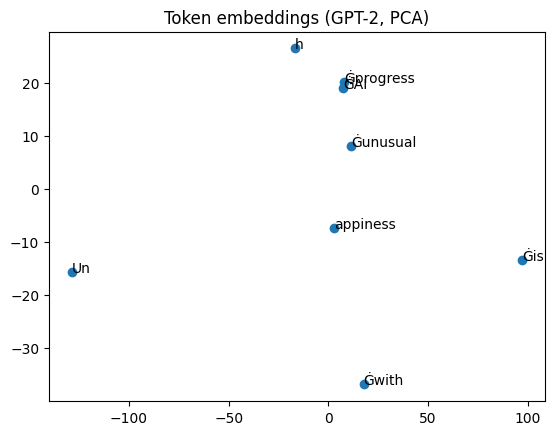

BERT tokens: ['un', '##ha', '##pp', '##iness', 'with', 'ai', 'progress', 'is', 'unusual']


In [1]:
# Setup
import torch
from transformers import GPT2Tokenizer, BertTokenizer, GPT2Model, BertModel
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# GPT-2 tokenizer & model
gpt_tok = GPT2Tokenizer.from_pretrained("gpt2")
gpt_model = GPT2Model.from_pretrained("gpt2")

text = "Unhappiness with AI progress is unusual"
tokens = gpt_tok.tokenize(text)
ids = gpt_tok.encode(text, return_tensors="pt")

print("GPT tokens:", tokens)

with torch.no_grad():
    embeddings = gpt_model(ids).last_hidden_state.squeeze(0)  # shape: (seq_len, hidden_dim)

# Reduce dimension for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings.numpy())

plt.scatter(reduced[:,0], reduced[:,1])
for i, tok in enumerate(tokens):
    plt.annotate(tok, (reduced[i,0], reduced[i,1]))
plt.title("Token embeddings (GPT-2, PCA)")
plt.show()

# BERT example
bert_tok = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

bert_tokens = bert_tok.tokenize(text)
print("BERT tokens:", bert_tokens)


1) Core (10–15 min)
Task: Tokenize "The runners are unstoppable" with GPT-2 and BERT. Compare tokens.

In [2]:
text = "The runners are unstoppable."

tokens = gpt_tok.tokenize(text)
print("GPT tokens:", tokens)

bert_tokens = bert_tok.tokenize(text)
print("BERT tokens:", bert_tokens)

GPT tokens: ['The', 'Ġrunners', 'Ġare', 'Ġunstoppable', '.']
BERT tokens: ['the', 'runners', 'are', 'un', '##sto', '##ppa', '##ble', '.']


GPT marks spaces with Ġ.

BERT marks subword continuations with ##.

2) Practice (10–15 min)
Task: Plot embeddings for tokens in "AI makes people happy and unhappy".

GPT tokens: ['AI', 'Ġmakes', 'Ġpeople', 'Ġhappy', 'Ġand', 'Ġunhappy']


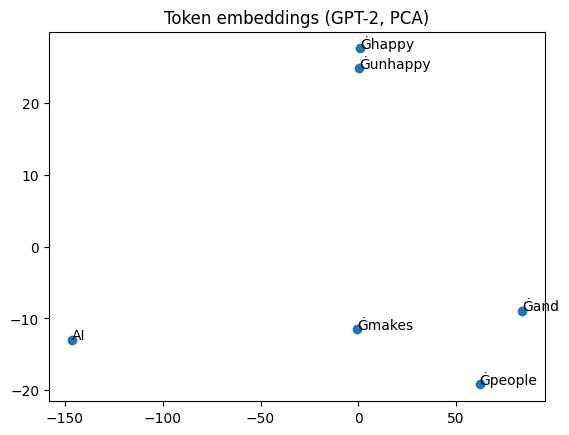

In [3]:
text = "AI makes people happy and unhappy"
tokens = gpt_tok.tokenize(text)
ids = gpt_tok.encode(text, return_tensors="pt")

print("GPT tokens:", tokens)

with torch.no_grad():
    embeddings = gpt_model(ids).last_hidden_state.squeeze(0)  # shape: (seq_len, hidden_dim)

# Reduce dimension for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings.numpy())

plt.scatter(reduced[:,0], reduced[:,1])
for i, tok in enumerate(tokens):
    plt.annotate(tok, (reduced[i,0], reduced[i,1]))
plt.title("Token embeddings (GPT-2, PCA)")
plt.show()


Similar subwords (“happy”, “unhappy”) are closer together 

3) Stretch (optional, 10–15 min)
Task: Train your own WordPiece tokenizer using Hugging Face tokenizers library on a small custom text file. Compare to GPT’s BPE.

In [ ]:
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from tokenizers.processors import TemplateProcessing
from pathlib import Path
from transformers import GPT2Tokenizer

# 1) Make a tiny custom corpus -----------------------------------------------
corpus = """
AI progress accelerates when data is clean and tasks are well defined.
Unhappiness with AI progress is unusual; dissatisfaction often means unclear goals.
The runners are unstoppable. They kept running and improving, step by step.
Unstoppable progress requires iteration, feedback, and careful evaluation.
"""
Path("mini_corpus.txt").write_text(corpus, encoding="utf-8")

# 2) Build & train a WordPiece tokenizer -------------------------------------
tok = Tokenizer(models.WordPiece(unk_token="[UNK]"))
tok.normalizer = normalizers.BertNormalizer(lowercase=True, strip_accents=True)
tok.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.WordPieceTrainer(
    vocab_size=1000,
    min_frequency=1,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)
tok.train(files=["mini_corpus.txt"], trainer=trainer)

# (optional but nice): add a post-processor to insert [CLS] ... [SEP]
tok.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    pair="[CLS] $A [SEP] $B:1 [SEP]:1",
    special_tokens=[("[CLS]", tok.token_to_id("[CLS]")), ("[SEP]", tok.token_to_id("[SEP]"))]
)

# Save the tokenizer (JSON) in case you want to reuse it
tok.save("mini_wordpiece.json")

# 3) Inspect a few vocab entries ---------------------------------------------
vocab = [tok.id_to_token(i) for i in range(min(50, tok.get_vocab_size()))]
print("Sample vocab tokens (first 50):")
print(vocab)

# 4) Compare tokenization to GPT-2 BPE ---------------------------------------
text = "Unhappiness with AI progress is unusual. The runners are unstoppable."
wp_enc = tok.encode(text)
print("\nWordPiece tokens:", wp_enc.tokens)

gpt_tok = GPT2Tokenizer.from_pretrained("gpt2")
print("GPT-2 BPE tokens:", gpt_tok.tokenize(text))

# 5) Quick notes you can paste into your reflection ---------------------------
print("\nNotes:")
print("- WordPiece splits unknown/rare words into base + '##' continuations (e.g., 'un' '##stop' '##pable'),")
print("  because it learns subwords that maximize likelihood on the *training corpus*.")
print("- GPT-2 BPE shows 'Ġ' to mark a leading space and merges frequent byte-pairs; its splits will differ.")
print("- With our tiny corpus, splits reflect what subwords appeared often in 'mini_corpus.txt'.")


Sample vocab tokens (first 50):
['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]', ',', '.', ';', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y', '##e', '##p', '##t', '##n', '##s', '##o', '##a', '##b', '##l', '##m', '##r', '##v', '##i', '##g', '##d', '##u', '##f', '##h', '##y']

WordPiece tokens: ['[CLS]', 'unhappiness', 'with', 'ai', 'progress', 'is', 'unusual', '.', 'the', 'runners', 'are', 'unstoppable', '.', '[SEP]']
GPT-2 BPE tokens: ['Un', 'h', 'appiness', 'Ġwith', 'ĠAI', 'Ġprogress', 'Ġis', 'Ġunusual', '.', 'ĠThe', 'Ġrunners', 'Ġare', 'Ġunstoppable', '.']

Notes:
- WordPiece splits unknown/rare words into base + '##' continuations (e.g., 'un' '##stop' '##pable'),
  because it learns subwords that maximize likelihood on the *training corpus*.
- GPT-2 BPE shows 'Ġ' to mark a leading space and merges frequent byte-pairs; its splits will differ.
- With our tiny corpus, splits reflect what subwords appeared often in 'mini

### 1. **We’re not loading a pretrained tokenizer**

Normally you call:

```python
BertTokenizer.from_pretrained("bert-base-uncased")
```

and you inherit Google’s huge, pre-trained WordPiece vocab.
Here instead, we are **training a tokenizer from scratch** on a *tiny custom corpus* (`mini_corpus.txt`).

---

### 2. **Using Hugging Face `tokenizers` library**

This lower-level library lets you design the **tokenizer algorithm** itself (WordPiece, BPE, Unigram, etc.), not just load one.
We explicitly build a **WordPiece tokenizer** with:

```python
tok = Tokenizer(models.WordPiece(unk_token="[UNK]"))
```

---

### 3. **Defining the training recipe**

* **Normalizer**: makes text consistent (`lowercase`, `strip_accents`) → like BERT’s preprocessing.
* **Pre-tokenizer**: splits on whitespace first.
* **Trainer**: decides vocab size, minimum frequency, and special tokens (`[PAD], [CLS], [SEP], [MASK]`).

This step is where we control how subwords are learned from the data.

---

### 4. **Adding post-processing**

We tell the tokenizer to automatically insert `[CLS]` at the start and `[SEP]` at the end — exactly how BERT expects inputs.
This isn’t automatic if you roll your own tokenizer, so we had to configure it.

---

### 5. **Saving and inspecting the vocab**

Unlike prebuilt tokenizers, we generate our own small vocab file (`mini_wordpiece.json`) and can inspect what subwords it learned.
Since the corpus is tiny, the vocab looks very different from BERT’s.

---

### 6. **Comparison to GPT-2 BPE**

Finally, we compare tokenization side by side:

* WordPiece tokens → `##` continuation pieces
* GPT-2 BPE tokens → `Ġ` space markers

That lets you **see concretely how the two algorithms split words differently** on the same text.

---

✅ **Special takeaway:**
We’re not just *using* a tokenizer — we’re **building one from scratch, controlling its rules, and seeing how its subword vocabulary emerges from the data.**
This makes it clear why GPT and BERT tokenize text differently, and how much the tokenizer itself shapes the model’s behavior.


Mini-Challenge (≤40 min)

Build a notebook exploring embeddings.

Input: at least 3 custom sentences.

Tokenize with GPT-2 and BERT.

Visualize embeddings (PCA or t-SNE).

Write a 2–3 sentence note: what words/subwords cluster together, why?

Acceptance Criteria

Shows both token lists.

Clear PCA plot with annotations.

Short written reflection on embedding similarity.

=== GPT-2 token lists (per sentence) ===
The runners are unstoppable.
['The', 'Ġrunners', 'Ġare', 'Ġunstoppable', '.']
Unhappiness with AI progress is unusual.
['Un', 'h', 'appiness', 'Ġwith', 'ĠAI', 'Ġprogress', 'Ġis', 'Ġunusual', '.']
Careful evaluation improves models over time.
['Care', 'ful', 'Ġevaluation', 'Ġimproves', 'Ġmodels', 'Ġover', 'Ġtime', '.']



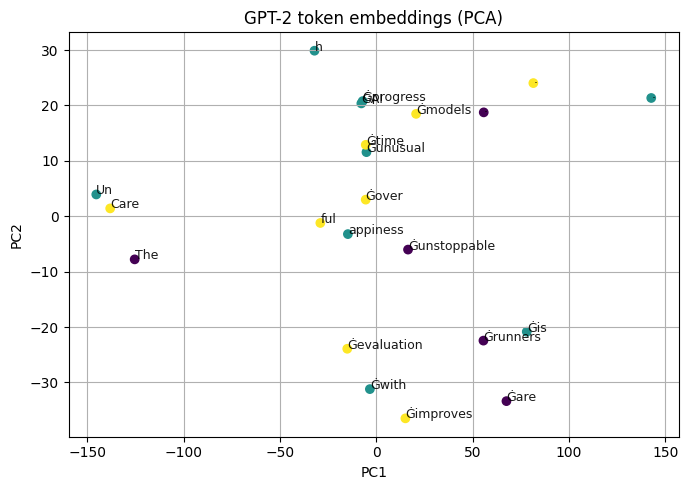

=== BERT token lists (per sentence) ===
The runners are unstoppable.
['the', 'runners', 'are', 'un', '##sto', '##ppa', '##ble', '.']
Unhappiness with AI progress is unusual.
['un', '##ha', '##pp', '##iness', 'with', 'ai', 'progress', 'is', 'unusual', '.']
Careful evaluation improves models over time.
['careful', 'evaluation', 'improves', 'models', 'over', 'time', '.']



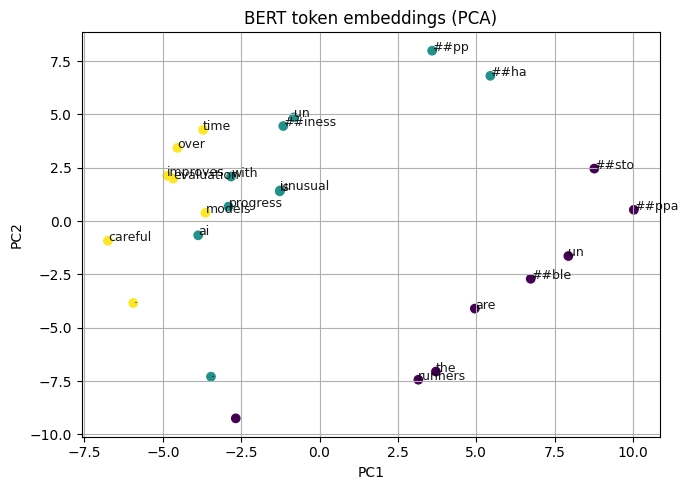

Reflection: Tokens that share stems or roles often cluster (e.g., subwords like '##able', '##ing', or semantically close words like 'progress/models'). BERT’s WordPiece splits show clusters of continuation pieces (##), while GPT-2’s BPE shows space-marked tokens (Ġ) grouping by word boundaries. Overall, morphological similarity and sentence context drive local neighborhoods in embedding space.


In [5]:
# Setup
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(42)
plt.rcParams["figure.figsize"] = (7,5)
plt.rcParams["axes.grid"] = True

import torch
from sklearn.decomposition import PCA
from transformers import GPT2Tokenizer, GPT2Model, BertTokenizer, BertModel

# ---- 1) Input: at least 3 custom sentences ---------------------------------
sentences = [
    "The runners are unstoppable.",
    "Unhappiness with AI progress is unusual.",
    "Careful evaluation improves models over time."
]

# ---- Helpers ----------------------------------------------------------------
def pca_2d(x):
    x = x - x.mean(0, keepdims=True)
    return PCA(n_components=2).fit_transform(x)

def plot_tokens_2d(points, tokens, colors, title):
    plt.figure()
    xs, ys = points[:,0], points[:,1]
    plt.scatter(xs, ys, c=colors)
    for (x, y, tok) in zip(xs, ys, tokens):
        plt.annotate(tok, (x, y), fontsize=9, alpha=0.9)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

# ---- 2) GPT-2: tokenize, embed, PCA, visualize ------------------------------
gpt_tok = GPT2Tokenizer.from_pretrained("gpt2")
gpt_model = GPT2Model.from_pretrained("gpt2")
gpt_model.eval()

gpt_all_tokens, gpt_all_vecs, gpt_colors = [], [], []
for si, s in enumerate(sentences):
    # GPT-2 has no special tokens by default; encode one sentence at a time
    ids = gpt_tok.encode(s, return_tensors="pt")
    with torch.no_grad():
        h = gpt_model(ids).last_hidden_state.squeeze(0)   # (seq, dim)
    toks = gpt_tok.convert_ids_to_tokens(ids.squeeze(0))
    # collect
    gpt_all_tokens.extend(toks)
    gpt_all_vecs.append(h.numpy())
    gpt_colors.extend([si]*len(toks))

gpt_all_vecs = np.vstack(gpt_all_vecs)
gpt_points = pca_2d(gpt_all_vecs)

print("=== GPT-2 token lists (per sentence) ===")
for s in sentences:
    print(s)
    print(gpt_tok.tokenize(s))
print()

plot_tokens_2d(gpt_points, gpt_all_tokens, gpt_colors, "GPT-2 token embeddings (PCA)")

# ---- 3) BERT: tokenize, embed, PCA, visualize -------------------------------
bert_tok = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()

bert_all_tokens, bert_all_vecs, bert_colors = [], [], []
for si, s in enumerate(sentences):
    enc = bert_tok(s, return_tensors="pt")
    with torch.no_grad():
        h = bert_model(**enc).last_hidden_state.squeeze(0)  # (seq, dim)
    toks = bert_tok.convert_ids_to_tokens(enc["input_ids"].squeeze(0))
    # Optionally drop [CLS]/[SEP] from plot:
    keep = [i for i,t in enumerate(toks) if t not in ("[CLS]","[SEP]")]
    toks = [toks[i] for i in keep]
    h = h[keep]
    # collect
    bert_all_tokens.extend(toks)
    bert_all_vecs.append(h.numpy())
    bert_colors.extend([si]*len(toks))

bert_all_vecs = np.vstack(bert_all_vecs)
bert_points = pca_2d(bert_all_vecs)

print("=== BERT token lists (per sentence) ===")
for s in sentences:
    print(s)
    print(bert_tok.tokenize(s))
print()

plot_tokens_2d(bert_points, bert_all_tokens, bert_colors, "BERT token embeddings (PCA)")

# ---- 4) Short reflection to print -------------------------------------------
reflection = (
    "Reflection: Tokens that share stems or roles often cluster (e.g., subwords like '##able', "
    "'##ing', or semantically close words like 'progress/models'). "
    "BERT’s WordPiece splits show clusters of continuation pieces (##), while GPT-2’s BPE shows "
    "space-marked tokens (Ġ) grouping by word boundaries. Overall, morphological similarity and "
    "sentence context drive local neighborhoods in embedding space."
)
print(reflection)


Notes / Key Takeaways

Tokenization is fundamental preprocessing for LLMs.

GPT/BERT use subword splits (BPE/WordPiece).

Embeddings map tokens into vector space where similar meanings cluster.

Visualization helps debug and interpret.

Differences in tokenization affect downstream model behavior.

Reflection

Why do models prefer subwords instead of full words?

What insight does plotting embeddings give us about meaning?

1) Why do models prefer subwords instead of full words?
Because the vocabulary is finite, full words would explode in size (millions of rare words). Subwords let models handle rare/novel words by breaking them into smaller reusable pieces (e.g., “unstoppable” → un + stop + ##able). This balances efficiency (small vocab) and coverage (any word can be expressed).

2) What insight does plotting embeddings give us about meaning?
Embedding plots show that tokens with similar form or usage cluster together — for example, morphological variants (run, running, ##able) or semantically related terms (progress, models). This reveals that the model’s geometry captures patterns of similarity, giving us a window into how meaning is represented.